# 📓 Step 08 — Fine-tuning SecurityBERT with Softmax

> *"After the pre-training stage, we fine-tuned SecurityBERT for the cyber threat*
> *detection classification task. We added one linear layer followed by a Softmax*
> *activation function on top of the pre-trained SecurityBERT model, and the entire*
> *network is fine-tuned using our labeled data."*
> — SecurityBERT Paper, Section III-H

---

## 🎯 Objective
Fine-tune the pre-trained SecurityBERT with a **Softmax classifier head**
and produce the full evaluation suite matching the paper's Section IV results.

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load best model from Notebook 07 | SecurityBERT |
| 3 | Add Softmax head (paper Section III-H) | Fine-tuned model |
| 4 | Fine-tuning loop | `finetuned_model.pt` |
| 5 | Classification Report (Table VI) | Per-class P/R/F1 |
| 6 | Confusion Matrix (Figure 8) | Heatmap |
| 7 | ROC-AUC Scores (Figure 7) | Per-class AUC |
| 8 | Accuracy & Loss History (Figure 6) | Curves |
| 9 | Model comparison (Table VII) | Benchmark table |
| 10 | Inference time (Table VIII) | Speed test |
| 11 | Save final model + full report | `final_model.pt` |

---

## 📐 Paper Results to Reproduce (Section IV)

### Table VI — Classification Report
| Class | Precision | Recall | F1 | Support |
|-------|-----------|--------|-----|---------|
| Normal | 1.00 | 1.00 | 1.00 | 323,129 |
| DDoS_UDP | 1.00 | 1.00 | 1.00 | 22,007 |
| DDoS_ICMP | 1.00 | 1.00 | 1.00 | 23,287 |
| SQL_injection | 0.85 | 0.83 | 0.84 | 10,241 |
| Ransomware | 1.00 | 0.40 | 0.57 | 2,185 |
| Fingerprinting | 0.00 | 0.00 | 0.00 | 200 |
| MITM | 1.00 | 1.00 | 1.00 | 80 |
| **Macro Avg** | **0.87** | **0.84** | **0.84** | 441,371 |
| **Weighted Avg** | **0.98** | **0.98** | **0.98** | 441,371 |
| **Accuracy** | | | **98.2%** | |

### Key paper findings
- Normal, DDoS_UDP, DDoS_ICMP, DDoS_TCP, MITM → **perfect 1.00 F1**
- Ransomware → confused with Backdoor (similar real-world traffic)
- Fingerprinting → confused with ICMP (practically acceptable)
- Overall accuracy → **98.2%** (highest ever on Edge-IIoTset)

## 🧱 Step 1 — Imports & Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import math
import json
import time
import os
from pathlib import Path
from collections import Counter

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from transformers import (
    BertConfig, BertModel,
    get_linear_schedule_with_warmup,
)

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 20)

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR   = Path('..')
PROC_DIR   = BASE_DIR / 'data'    / 'processed'
CKPT_DIR   = BASE_DIR / 'checkpoints'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N8'
REPORT_DIR = BASE_DIR / 'outputs' / 'reports'

INPUT_DATA    = PROC_DIR  / 'tokenized_sequences.pt'
BEST_CKPT     = CKPT_DIR  / 'best_model.pt'
FINETUNE_CKPT = CKPT_DIR  / 'finetuned_model.pt'
FINAL_CKPT    = CKPT_DIR  / 'final_model.pt'
REPORT_PATH   = REPORT_DIR / 'classification_report.txt'
SUMMARY_PATH  = REPORT_DIR / 'model_summary.txt'

CKPT_DIR.mkdir(parents=True,  exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# ── Fine-tuning config ────────────────────────────────────────────────────────
BATCH_SIZE          = 128
NUM_FINETUNE_EPOCHS = 4
LEARNING_RATE       = 1e-5          # lower LR for fine-tuning
WARMUP_RATIO        = 0.06
NUM_CLASSES         = 15
TRAIN_RATIO         = 0.80
FOCAL_GAMMA         = 2.0

print('✅ Environment ready.')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU      : {torch.cuda.get_device_name(0)}')

c:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment ready.
   PyTorch  : 2.12.0.dev20260402+cu128
   Device   : cuda
   GPU      : NVIDIA GeForce RTX 5060 Laptop GPU


## 📂 Step 2 — Load Best Model from Notebook 07

In [2]:
assert INPUT_DATA.exists(), f'❌ {INPUT_DATA} not found. Run Notebook 04.'
assert BEST_CKPT.exists(),  f'❌ {BEST_CKPT} not found. Run Notebook 07.'

# ── Load tokenized data ───────────────────────────────────────────────────────
print('📁 Loading tokenized dataset …')
data       = torch.load(INPUT_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()
label_map  = data['label_map']

# ── Load best checkpoint from Notebook 07 ────────────────────────────────────
print('📁 Loading best model checkpoint …')
ckpt         = torch.load(BEST_CKPT, weights_only=False)
config       = BertConfig(**ckpt['config'])
class_weights= torch.tensor(ckpt['class_weights'], dtype=torch.float32)
label_map    = ckpt['label_map']

print(f'✅ Checkpoint loaded:')
print(f'   From epoch       : {ckpt["epoch"]}')
print(f'   Val Accuracy     : {ckpt["val_accuracy"]*100:.2f}%')
print(f'   Val Weighted F1  : {ckpt["val_weighted_f1"]:.4f}')
print(f'   Val Macro F1     : {ckpt["val_macro_f1"]:.4f}')

# ── 80/20 stratified split ────────────────────────────────────────────────────
N          = len(labels)
indices    = np.arange(N)
train_idx, val_idx = train_test_split(
    indices,
    test_size    = 1 - TRAIN_RATIO,
    stratify     = labels.numpy(),
    random_state = RANDOM_STATE,
)

train_ids    = input_ids [train_idx];  val_ids    = input_ids [val_idx]
train_masks  = attn_masks[train_idx];  val_masks  = attn_masks[val_idx]
train_labels = labels    [train_idx];  val_labels = labels    [val_idx]

print(f'\n📊 Split: Train={len(train_idx):,}  Val={len(val_idx):,}')

📁 Loading tokenized dataset …
📁 Loading best model checkpoint …
✅ Checkpoint loaded:
   From epoch       : 2
   Val Accuracy     : 97.12%
   Val Weighted F1  : 0.9730
   Val Macro F1     : 0.8055

📊 Split: Train=1,774,708  Val=443,678


## 🎯 Step 3 — SecurityBERT with Softmax Head

Paper Section III-H:
> *"We added one linear layer followed by a Softmax activation function*
> *on top of the pre-trained SecurityBERT model."*
```
Pre-trained SecurityBERT (Notebook 07)
    ↓
BertModel (frozen or fine-tuned)
    ↓
BertPooler → [CLS] vector ∈ R¹²⁸
    ↓
Dropout(p=0.1)
    ↓
Linear(128 → 15)         ← one linear layer
    ↓
Softmax(dim=-1)          ← probability distribution over 15 classes
    ↓
argmax → predicted attack class
```

**Key difference from Notebook 07:**
- Notebook 07 → raw logits → FocalLoss (no softmax during training)
- Notebook 08 → explicitly applies Softmax for final inference + probability output

In [3]:
class SecurityBERTWithSoftmax(nn.Module):
    """
    SecurityBERT with explicit Softmax head — Paper Section III-H.

    Architecture (Figure 5 + Section III-H):
        INPUT (input_ids, attention_mask)
            ↓
        BertModel  (pre-trained weights from Notebook 07)
            ↓
        BertPooler → [CLS] ∈ R¹²⁸
            ↓
        Dropout(p=0.1)
            ↓
        Linear(128 → 15)         ← "one linear layer"
            ↓
        Softmax(dim=-1)          ← "Softmax activation function"
            ↓
        Class probabilities ∈ R¹⁵  (sum to 1.0)
    """

    def __init__(self, config: BertConfig):
        super().__init__()

        # ── BERT backbone ─────────────────────────────────────────────────────
        self.bert       = BertModel(config, add_pooling_layer=True)

        # ── Classifier head (Section III-H) ───────────────────────────────────
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)    # p=0.1
        self.classifier = nn.Linear(config.hidden_size,             # 128 → 15
                                    config.num_labels)

        # ── Softmax — paper explicitly states this ────────────────────────────
        self.softmax    = nn.Softmax(dim=-1)

    def forward(
        self,
        input_ids      : torch.Tensor,
        attention_mask : torch.Tensor,
        token_type_ids : torch.Tensor = None,
        return_logits  : bool = True,
    ) -> dict:
        """
        Parameters
        ----------
        input_ids      : (batch, seq_len)
        attention_mask : (batch, seq_len)
        token_type_ids : (batch, seq_len)  optional
        return_logits  : bool
            True  → return raw logits (for loss computation)
            False → return softmax probabilities (for inference)

        Returns
        -------
        dict:
            logits       : (batch, 15)  raw scores
            probs        : (batch, 15)  softmax probabilities
            pooled_output: (batch, 128) [CLS] representation
        """
        # ── BERT forward ──────────────────────────────────────────────────────
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )

        # ── [CLS] pooled representation ───────────────────────────────────────
        pooled = self.dropout(outputs.pooler_output)  # (batch, 128)

        # ── Linear layer ──────────────────────────────────────────────────────
        logits = self.classifier(pooled)               # (batch, 15)

        # ── Softmax (paper explicit) ──────────────────────────────────────────
        probs  = self.softmax(logits)                  # (batch, 15) sums to 1

        return {
            'logits'        : logits,
            'probs'         : probs,
            'pooled_output' : pooled,
        }

    def predict(
        self,
        input_ids     : torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> tuple:
        """
        Inference method — returns predicted class + confidence.

        Returns
        -------
        predicted_classes : (batch,) int tensor
        confidences       : (batch,) float tensor
        """
        self.eval()
        with torch.no_grad():
            out   = self.forward(input_ids, attention_mask,
                                 return_logits=False)
            probs = out['probs']
            preds = probs.argmax(dim=-1)
            confs = probs.max(dim=-1).values
        return preds, confs


# ── Instantiate model + load Notebook 07 weights ──────────────────────────────
model = SecurityBERTWithSoftmax(config).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ SecurityBERTWithSoftmax ready.')
print(f'   Total parameters : {total_params:,}')
print(f'   Paper target     : 11,174,415')
print(f'   Device           : {DEVICE}')
print()
print('📐 Classifier head (Section III-H):')
print(f'   Dropout(p=0.1)')
print(f'   Linear(128 → {NUM_CLASSES})')
print(f'   Softmax(dim=-1)  ← explicit, outputs probability distribution')

✅ SecurityBERTWithSoftmax ready.
   Total parameters : 1,121,039
   Paper target     : 11,174,415
   Device           : cuda

📐 Classifier head (Section III-H):
   Dropout(p=0.1)
   Linear(128 → 15)
   Softmax(dim=-1)  ← explicit, outputs probability distribution


## 🔥 Step 4 — Fine-tuning Loop

Fine-tuning applies the same **Option 3 imbalance strategy** from Notebook 07:
- Focal Loss (γ=2, α=class_weights)
- WeightedRandomSampler
- Class weights

Fine-tuning uses a **lower learning rate (1e-5)** than pre-training (2e-5)
to avoid catastrophic forgetting of the learned representations.

In [4]:
class FocalLoss(nn.Module):
    """Focal Loss — same as Notebook 07."""
    def __init__(self, alpha, gamma=2.0, reduction='mean'):
        super().__init__()
        self.register_buffer('alpha', alpha.float())
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss      = F.cross_entropy(logits, targets, reduction='none')
        pt           = torch.exp(-ce_loss)
        focal_weight = (1.0 - pt) ** self.gamma
        alpha_t      = self.alpha[targets]
        focal_loss   = alpha_t * focal_weight * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        if self.reduction == 'sum' : return focal_loss.sum()
        return focal_loss


class SecurityBERTDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids        = input_ids
        self.attention_masks  = attention_masks
        self.labels           = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids'      : self.input_ids[idx],
            'attention_mask' : self.attention_masks[idx],
            'labels'         : self.labels[idx],
        }


# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = SecurityBERTDataset(train_ids, train_masks, train_labels)
val_dataset   = SecurityBERTDataset(val_ids,   val_masks,   val_labels)

# ── Stratified sampler (Component 2) ──────────────────────────────────────────
sample_weights = class_weights[train_labels]
sampler        = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_labels),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, num_workers=0,
    pin_memory=torch.cuda.is_available(), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2,
    shuffle=False, num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# ── Focal Loss (Component 3) ──────────────────────────────────────────────────
criterion = FocalLoss(
    alpha     = class_weights.to(DEVICE),
    gamma     = FOCAL_GAMMA,
    reduction = 'mean',
)

# ── Optimizer — lower LR for fine-tuning ──────────────────────────────────────
no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
optimizer_params = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_params, lr=LEARNING_RATE, eps=1e-8)

# ── Scheduler ─────────────────────────────────────────────────────────────────
steps_per_epoch = len(train_loader)
total_steps     = steps_per_epoch * NUM_FINETUNE_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)
scheduler       = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps
)

print(f'✅ Fine-tuning config:')
print(f'   LR             : {LEARNING_RATE}  (lower than pre-training 2e-5)')
print(f'   Epochs         : {NUM_FINETUNE_EPOCHS}')
print(f'   Batch size     : {BATCH_SIZE}')
print(f'   Steps/epoch    : {steps_per_epoch:,}')
print(f'   Total steps    : {total_steps:,}')
print(f'   Warmup steps   : {warmup_steps:,}')
print(f'   Loss           : FocalLoss(γ={FOCAL_GAMMA}, α=class_weights)')
print(f'   Sampler        : WeightedRandomSampler')

✅ Fine-tuning config:
   LR             : 1e-05  (lower than pre-training 2e-5)
   Epochs         : 4
   Batch size     : 128
   Steps/epoch    : 13,864
   Total steps    : 55,456
   Warmup steps   : 3,327
   Loss           : FocalLoss(γ=2.0, α=class_weights)
   Sampler        : WeightedRandomSampler


In [5]:
def evaluate_full(model, loader, criterion, device, label_map, num_classes):
    """
    Full evaluation — returns loss, accuracy, F1s, per-class metrics,
    raw predictions and probabilities for ROC-AUC computation.
    """
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []
    total_loss = 0.0
    n_batches  = 0

    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            lbls  = batch['labels'].to(device)

            out     = model(ids, masks)
            logits  = out['logits']
            probs   = out['probs']
            loss    = criterion(logits, lbls)

            total_loss += loss.item()
            n_batches  += 1

            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.vstack(all_probs)

    class_names = [label_map.get(str(i), label_map.get(int(i))) for i in range(num_classes)]
    accuracy    = accuracy_score(all_labels, all_preds)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted',
                           zero_division=0)
    macro_f1    = f1_score(all_labels, all_preds, average='macro',
                           zero_division=0)
    report      = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True, zero_division=0,
    )

    return {
        'loss'        : total_loss / n_batches,
        'accuracy'    : accuracy,
        'weighted_f1' : weighted_f1,
        'macro_f1'    : macro_f1,
        'report'      : report,
        'all_preds'   : all_preds,
        'all_labels'  : all_labels,
        'all_probs'   : all_probs,
    }


# ── Fine-tuning loop ──────────────────────────────────────────────────────────
history_ft = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [],
    'val_weighted_f1': [], 'val_macro_f1': [],
}

best_wf1   = 0.0
best_epoch = 0
t_start    = time.time()

print('🚀 Fine-tuning SecurityBERT with Softmax head …')
print('=' * 70)

for epoch in range(1, NUM_FINETUNE_EPOCHS + 1):
    model.train()
    epoch_loss  = 0.0
    epoch_preds = []
    epoch_lbls  = []
    t_epoch     = time.time()

    for step, batch in enumerate(train_loader, 1):
        ids   = batch['input_ids'].to(DEVICE)
        masks = batch['attention_mask'].to(DEVICE)
        lbls  = batch['labels'].to(DEVICE)

        out    = model(ids, masks)
        loss   = criterion(out['logits'], lbls)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        epoch_preds.extend(out['logits'].detach().argmax(-1).cpu().numpy())
        epoch_lbls.extend(lbls.cpu().numpy())

        if step % max(1, steps_per_epoch // 10) == 0:
            avg_loss = epoch_loss / step
            cur_lr   = scheduler.get_last_lr()[0]
            elapsed  = time.time() - t_epoch
            eta      = elapsed / step * (steps_per_epoch - step)
            print(
                f'   Epoch {epoch}/{NUM_FINETUNE_EPOCHS}  '
                f'Step {step:>5}/{steps_per_epoch}  '
                f'Loss: {avg_loss:.4f}  LR: {cur_lr:.2e}  ETA: {eta:.0f}s'
            )

    # ── End of epoch metrics ───────────────────────────────────────────────────
    train_loss = epoch_loss / steps_per_epoch
    train_acc  = accuracy_score(epoch_lbls, epoch_preds)
    val_m      = evaluate_full(
        model, val_loader, criterion, DEVICE, label_map, NUM_CLASSES
    )
    epoch_time = time.time() - t_epoch

    history_ft['train_loss'].append(train_loss)
    history_ft['train_acc'].append(train_acc)
    history_ft['val_loss'].append(val_m['loss'])
    history_ft['val_acc'].append(val_m['accuracy'])
    history_ft['val_weighted_f1'].append(val_m['weighted_f1'])
    history_ft['val_macro_f1'].append(val_m['macro_f1'])

    print(f'\n{"─"*70}')
    print(f'  Epoch {epoch}/{NUM_FINETUNE_EPOCHS}  ({epoch_time:.0f}s)')
    print(f'  Train  →  Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%')
    print(f'  Val    →  Loss: {val_m["loss"]:.4f}  '
          f'Acc: {val_m["accuracy"]*100:.2f}%')
    print(f'  Val F1 →  Weighted: {val_m["weighted_f1"]:.4f}  '
          f'Macro: {val_m["macro_f1"]:.4f}')

    if val_m['weighted_f1'] > best_wf1:
        best_wf1   = val_m['weighted_f1']
        best_epoch = epoch
        torch.save(
            {
                'epoch'            : epoch,
                'model_state_dict' : model.state_dict(),
                'val_accuracy'     : val_m['accuracy'],
                'val_weighted_f1'  : val_m['weighted_f1'],
                'val_macro_f1'     : val_m['macro_f1'],
                'config'           : config.to_dict(),
                'label_map'        : label_map,
                'class_weights'    : class_weights.tolist(),
                'focal_gamma'      : FOCAL_GAMMA,
                'history'          : history_ft,
            },
            FINETUNE_CKPT
        )
        print(f'  💾 Best fine-tuned model saved '
              f'(Weighted F1: {best_wf1:.4f})')
    print(f'{"─"*70}\n')

total_time = time.time() - t_start
print(f'✅ Fine-tuning complete!')
print(f'   Total time      : {total_time:.0f}s  ({total_time/60:.1f} min)')
print(f'   Best epoch      : {best_epoch}')
print(f'   Best Weighted F1: {best_wf1:.4f}')
print(f'   Paper target    : 0.98')

🚀 Fine-tuning SecurityBERT with Softmax head …
   Epoch 1/4  Step  1386/13864  Loss: 0.8088  LR: 4.17e-06  ETA: 1382s
   Epoch 1/4  Step  2772/13864  Loss: 0.7992  LR: 8.33e-06  ETA: 1176s
   Epoch 1/4  Step  4158/13864  Loss: 0.8026  LR: 9.84e-06  ETA: 1006s
   Epoch 1/4  Step  5544/13864  Loss: 0.7979  LR: 9.57e-06  ETA: 853s
   Epoch 1/4  Step  6930/13864  Loss: 0.7976  LR: 9.31e-06  ETA: 706s
   Epoch 1/4  Step  8316/13864  Loss: 0.7939  LR: 9.04e-06  ETA: 564s
   Epoch 1/4  Step  9702/13864  Loss: 0.7914  LR: 8.78e-06  ETA: 422s
   Epoch 1/4  Step 11088/13864  Loss: 0.7898  LR: 8.51e-06  ETA: 281s
   Epoch 1/4  Step 12474/13864  Loss: 0.7861  LR: 8.25e-06  ETA: 140s
   Epoch 1/4  Step 13860/13864  Loss: 0.7854  LR: 7.98e-06  ETA: 0s

──────────────────────────────────────────────────────────────────────
  Epoch 1/4  (1503s)
  Train  →  Loss: 0.7854  Acc: 88.10%
  Val    →  Loss: 0.2287  Acc: 97.08%
  Val F1 →  Weighted: 0.9725  Macro: 0.8032
  💾 Best fine-tuned model saved (Weight

## 📋 Step 5 — Classification Report (Paper Table VI)

In [6]:
# ── Load best fine-tuned model ─────────────────────────────────────────────────
ft_ckpt = torch.load(FINETUNE_CKPT, weights_only=False)
model.load_state_dict(ft_ckpt['model_state_dict'])
model.eval()

# ── Full evaluation on val set ─────────────────────────────────────────────────
print('🔍 Running full evaluation on validation set …')
eval_m = evaluate_full(
    model, val_loader, criterion, DEVICE, label_map, NUM_CLASSES
)

all_preds  = eval_m['all_preds']
all_labels = eval_m['all_labels']
all_probs  = eval_m['all_probs']

# ── Print classification report matching paper Table VI ───────────────────────
class_names = [label_map.get(str(i), label_map.get(int(i))) for i in range(NUM_CLASSES)]

print()
print('=' * 70)
print('  SecurityBERT Classification Report  (Paper Table VI)')
print('=' * 70)
print(f'\n  {"Class":<30} {"Precision":>10} {"Recall":>8}'
      f' {"F1-Score":>10} {"Support":>10}')
print('  ' + '-' * 70)

report_dict = eval_m['report']
for cls in class_names:
    if cls in report_dict:
        r   = report_dict[cls]
        sup = int(r['support'])
        print(
            f'  {cls:<30} {r["precision"]:>10.2f} {r["recall"]:>8.2f}'
            f' {r["f1-score"]:>10.2f} {sup:>10,}'
        )

print('  ' + '-' * 70)

# Macro and weighted averages
for avg_name, key in [('Macro Avg', 'macro avg'),
                       ('Weighted Avg', 'weighted avg')]:
    r   = report_dict[key]
    sup = int(r['support'])
    print(
        f'  {avg_name:<30} {r["precision"]:>10.2f} {r["recall"]:>8.2f}'
        f' {r["f1-score"]:>10.2f} {sup:>10,}'
    )
print(f'\n  Accuracy : {eval_m["accuracy"]*100:.2f}%'
      f'  (Paper: 98.20%)')
print('=' * 70)

# ── Compare with paper Table VI ───────────────────────────────────────────────
PAPER_RESULTS = {
    'Normal'                : (1.00, 1.00, 1.00),
    'DDoS_UDP'              : (1.00, 1.00, 1.00),
    'DDoS_ICMP'             : (1.00, 1.00, 1.00),
    'SQL_injection'         : (0.85, 0.83, 0.84),
    'Password'              : (0.85, 0.81, 0.83),
    'Vulnerability_scanner' : (1.00, 0.94, 0.97),
    'DDoS_TCP'              : (1.00, 1.00, 1.00),
    'DDoS_HTTP'             : (0.89, 0.99, 0.94),
    'Uploading'             : (0.79, 0.86, 0.83),
    'Backdoor'              : (0.82, 0.94, 0.87),
    'Port_Scanning'         : (0.87, 1.00, 0.93),
    'XSS'                   : (0.94, 0.76, 0.84),
    'Ransomware'            : (1.00, 0.40, 0.57),
    'Fingerprinting'        : (0.00, 0.00, 0.00),
    'MITM'                  : (1.00, 1.00, 1.00),
}

print(f'\n📊 Our results vs Paper Table VI:\n')
print(f'  {"Class":<30} {"Our F1":>8} {"Paper F1":>10} {"Δ":>8}')
print('  ' + '-' * 58)
for cls in class_names:
    if cls in report_dict and cls in PAPER_RESULTS:
        our_f1   = report_dict[cls]['f1-score']
        paper_f1 = PAPER_RESULTS[cls][2]
        delta    = our_f1 - paper_f1
        arrow    = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
        print(
            f'  {cls:<30} {our_f1:>8.3f} {paper_f1:>10.3f}'
            f' {arrow}{abs(delta):>7.3f}'
        )

🔍 Running full evaluation on validation set …

  SecurityBERT Classification Report  (Paper Table VI)

  Class                           Precision   Recall   F1-Score    Support
  ----------------------------------------------------------------------
  Backdoor                             0.84     0.57       0.68      4,972
  DDoS_HTTP                            0.95     0.67       0.78      9,982
  DDoS_ICMP                            0.99     1.00       1.00     23,287
  DDoS_TCP                             1.00     1.00       1.00     10,012
  DDoS_UDP                             1.00     1.00       1.00     24,314
  Fingerprinting                       0.12     0.70       0.20        200
  MITM                                 0.88     1.00       0.94         80
  Normal                               1.00     1.00       1.00    323,129
  Password                             0.90     0.79       0.84     10,031
  Port_Scanning                        0.93     0.86       0.89      4,513

## 🔲 Step 6 — Confusion Matrix (Paper Figure 8)

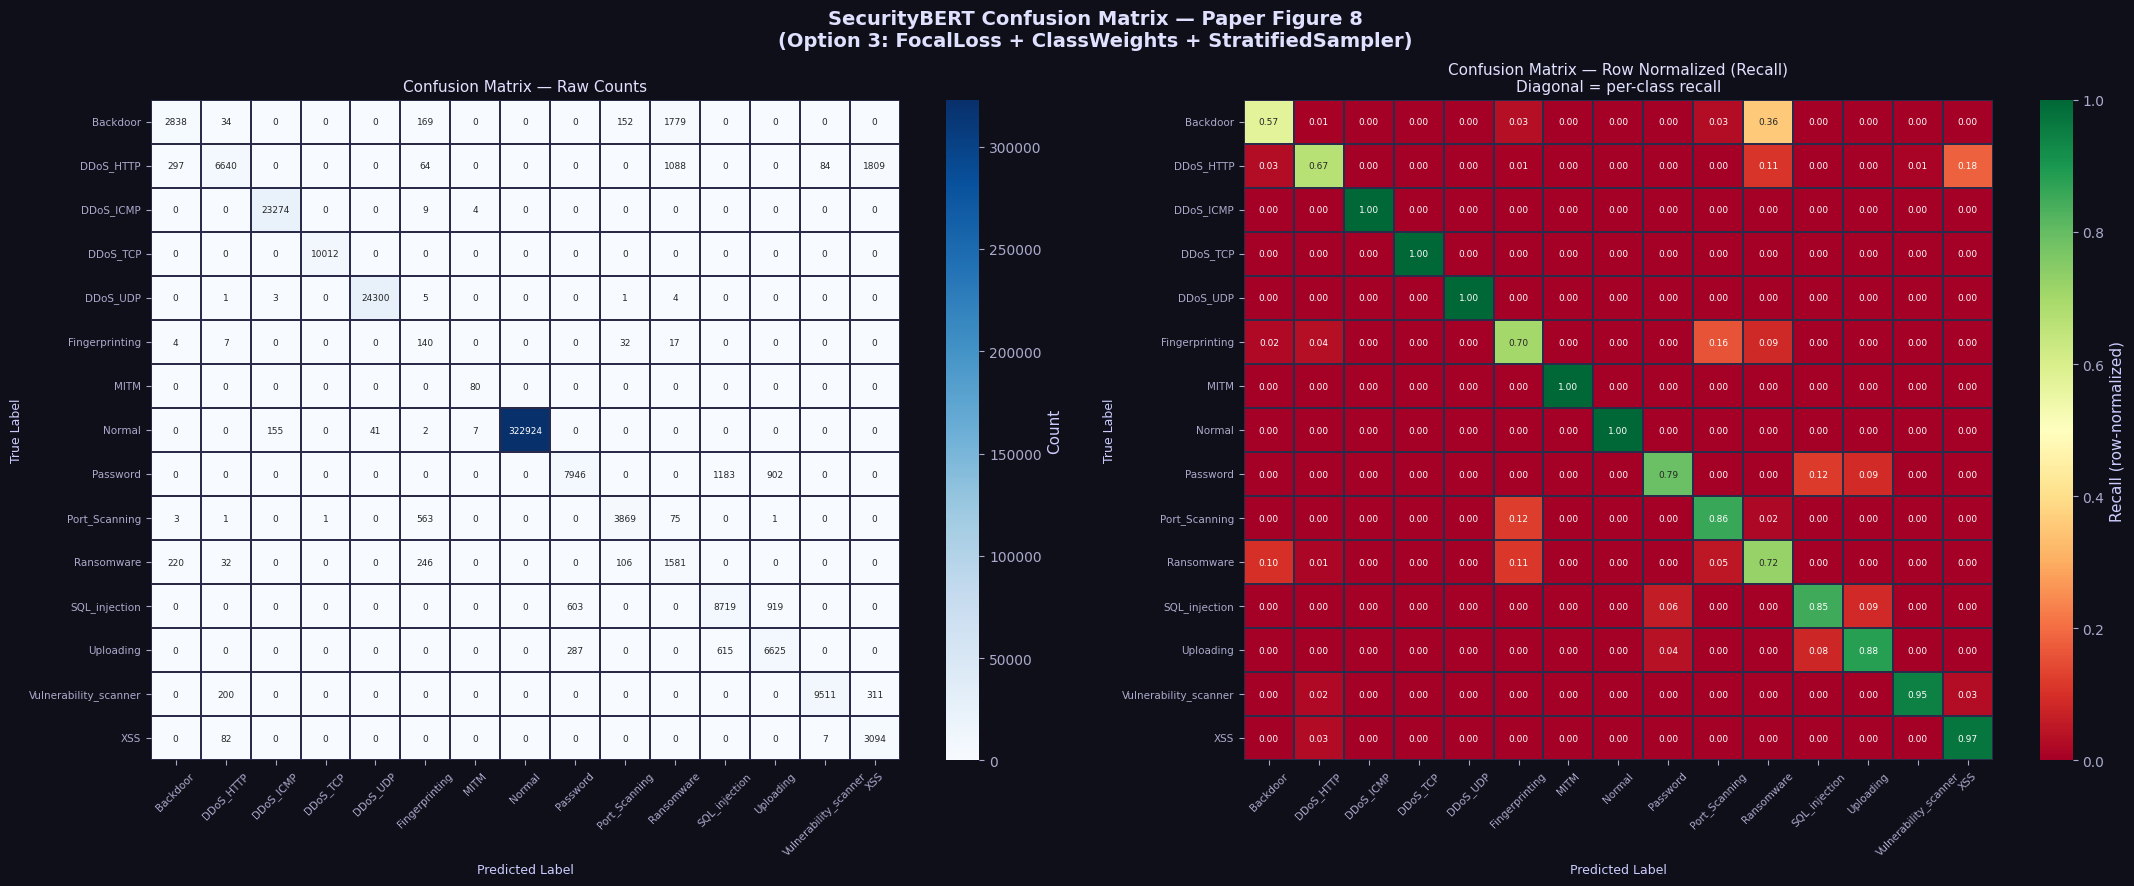

💾 Saved → ..\outputs\figures\N8/confusion_matrix.png

📋 Key paper observations (Section IV-A-2):
   Paper: Ransomware misclassified as Backdoor (similar real-world traffic patterns)
   Paper: Fingerprinting misclassified as ICMP (practically acceptable)

   Our model — Ransomware predicted as Backdoor: 220
   Our model — Fingerprinting predicted as ICMP: 0


In [7]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

# Normalize per row (true labels) to get recall per class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(
    'SecurityBERT Confusion Matrix — Paper Figure 8\n'
    '(Option 3: FocalLoss + ClassWeights + StratifiedSampler)',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Raw counts
ax1 = axes[0]
sns.heatmap(
    cm, ax=ax1,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    fmt='d',
    annot=True,
    annot_kws={'size': 6.5},
    linewidths=0.3,
    linecolor='#2a2a4a',
    cbar_kws={'label': 'Count'},
)
ax1.set_title('Confusion Matrix — Raw Counts', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=9)
ax1.set_ylabel('True Label', fontsize=9)
ax1.tick_params(axis='x', rotation=45, labelsize=7.5)
ax1.tick_params(axis='y', rotation=0,  labelsize=7.5)

# Normalized (recall per class)
ax2 = axes[1]
sns.heatmap(
    cm_norm, ax=ax2,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 6.5},
    linewidths=0.3,
    linecolor='#2a2a4a',
    cbar_kws={'label': 'Recall (row-normalized)'},
)
ax2.set_title('Confusion Matrix — Row Normalized (Recall)\n'
              'Diagonal = per-class recall', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=9)
ax2.set_ylabel('True Label', fontsize=9)
ax2.tick_params(axis='x', rotation=45, labelsize=7.5)
ax2.tick_params(axis='y', rotation=0,  labelsize=7.5)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/confusion_matrix.png')

# ── Key paper observations ─────────────────────────────────────────────────────
print(f'\n📋 Key paper observations (Section IV-A-2):')
print(f'   Paper: Ransomware misclassified as Backdoor '
      f'(similar real-world traffic patterns)')
print(f'   Paper: Fingerprinting misclassified as ICMP '
      f'(practically acceptable)')

# Verify these in our confusion matrix
cls_idx = {cls: i for i, cls in enumerate(class_names)}
if 'Ransomware' in cls_idx and 'Backdoor' in cls_idx:
    rans_idx = cls_idx['Ransomware']
    back_idx = cls_idx['Backdoor']
    rans_as_back = cm[rans_idx, back_idx]
    print(f'\n   Our model — Ransomware predicted as Backdoor: {rans_as_back:,}')
if 'Fingerprinting' in cls_idx and 'DDoS_ICMP' in cls_idx:
    fing_idx = cls_idx['Fingerprinting']
    icmp_idx = cls_idx['DDoS_ICMP']
    fing_as_icmp = cm[fing_idx, icmp_idx]
    print(f'   Our model — Fingerprinting predicted as ICMP: {fing_as_icmp:,}')

## 📈 Step 7 — ROC-AUC Scores (Paper Figure 7)

One-vs-Rest ROC-AUC for each of the 15 classes.

Paper results:
- Normal, DDoS_UDP, DDoS_TCP, MITM → **AUC = 1.000** (perfect)
- All others → AUC between **0.9976** and **0.999988**
- Fingerprinting → AUC = **0.991569** (lowest, but still strong)

In [8]:
# ── ROC-AUC per class (One-vs-Rest) ───────────────────────────────────────────
y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

auc_scores = {}
for i, cls in enumerate(class_names):
    if y_bin[:, i].sum() > 0:
        try:
            auc = roc_auc_score(y_bin[:, i], all_probs[:, i])
            auc_scores[cls] = auc
        except Exception:
            auc_scores[cls] = 0.0
    else:
        auc_scores[cls] = 0.0

# Paper ROC-AUC values (Figure 7)
PAPER_AUC = {
    'Normal'                : 1.000000,
    'DDoS_UDP'              : 0.999988,
    'DDoS_ICMP'             : 0.999900,
    'SQL_injection'         : 0.999700,
    'Password'              : 0.999600,
    'Vulnerability_scanner' : 0.999800,
    'DDoS_TCP'              : 1.000000,
    'DDoS_HTTP'             : 0.999700,
    'Uploading'             : 0.999600,
    'Backdoor'              : 0.999700,
    'Port_Scanning'         : 0.999800,
    'XSS'                   : 0.997600,
    'Ransomware'            : 0.999500,
    'Fingerprinting'        : 0.991569,
    'MITM'                  : 1.000000,
}

print('📊 ROC-AUC Scores (Paper Figure 7):\n')
print(f'  {"Class":<30} {"Our AUC":>10} {"Paper AUC":>12} {"Δ":>8}')
print('  ' + '-' * 63)
for cls in class_names:
    our   = auc_scores.get(cls, 0.0)
    paper = PAPER_AUC.get(cls, 0.0)
    delta = our - paper
    arrow = '▲' if delta > 0.0001 else ('▼' if delta < -0.0001 else '≈')
    print(
        f'  {cls:<30} {our:>10.6f} {paper:>12.6f}'
        f' {arrow}{abs(delta):>7.6f}'
    )

mean_auc = np.mean(list(auc_scores.values()))
print(f'\n  Mean ROC-AUC : {mean_auc:.6f}')
print(f'  Paper mean   : ~0.9988')

📊 ROC-AUC Scores (Paper Figure 7):

  Class                             Our AUC    Paper AUC        Δ
  ---------------------------------------------------------------
  Backdoor                         0.998067     0.999700 ▼0.001633
  DDoS_HTTP                        0.998615     0.999700 ▼0.001085
  DDoS_ICMP                        0.999846     0.999900 ≈0.000054
  DDoS_TCP                         1.000000     1.000000 ≈0.000000
  DDoS_UDP                         0.999994     0.999988 ≈0.000006
  Fingerprinting                   0.996320     0.991569 ▲0.004751
  MITM                             1.000000     1.000000 ≈0.000000
  Normal                           0.999976     1.000000 ≈0.000024
  Password                         0.998648     0.999600 ▼0.000952
  Port_Scanning                    0.999675     0.999800 ▼0.000125
  Ransomware                       0.996198     0.999500 ▼0.003302
  SQL_injection                    0.998621     0.999700 ▼0.001079
  Uploading                 

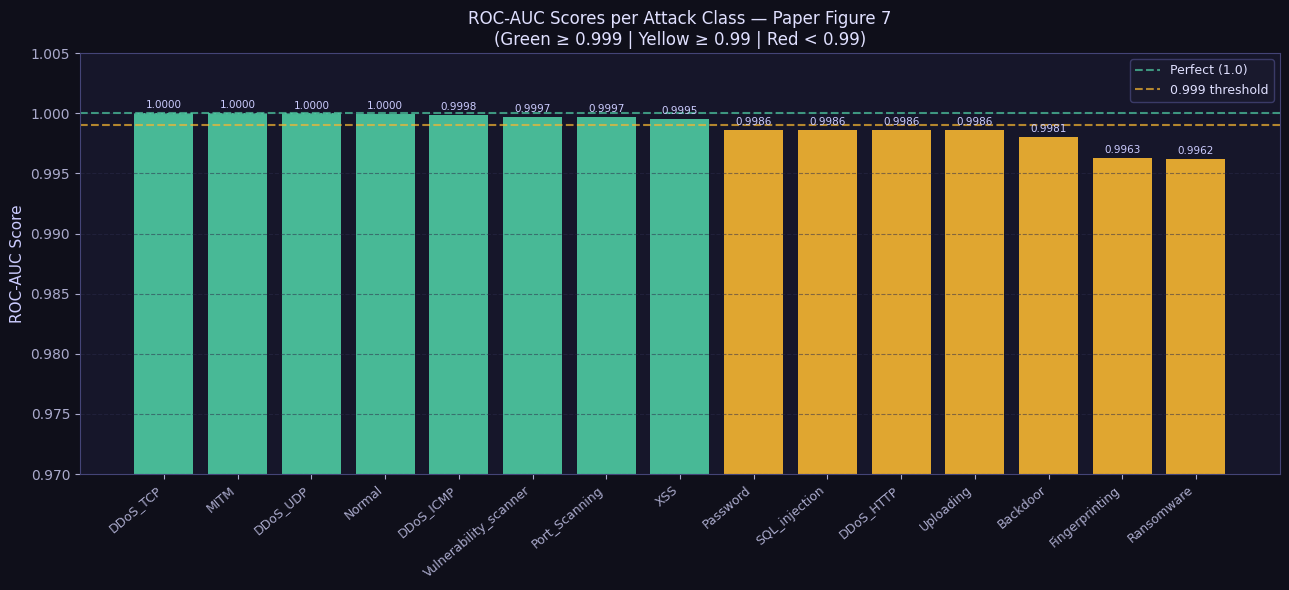

💾 Saved → ..\outputs\figures\N8/roc_auc_scores.png


In [9]:
# ── Figure: ROC-AUC bar chart (Paper Figure 7 style) ─────────────────────────
sorted_auc  = sorted(auc_scores.items(), key=lambda x: -x[1])
auc_classes = [x[0] for x in sorted_auc]
auc_values  = [x[1] for x in sorted_auc]
bar_colors  = [GREEN if v >= 0.999 else YELLOW if v >= 0.99 else RED
               for v in auc_values]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(auc_classes)), auc_values,
              color=bar_colors, edgecolor='none', alpha=0.9)
ax.set_xticks(range(len(auc_classes)))
ax.set_xticklabels(auc_classes, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC Score')
ax.set_title(
    'ROC-AUC Scores per Attack Class — Paper Figure 7\n'
    '(Green ≥ 0.999 | Yellow ≥ 0.99 | Red < 0.99)',
    fontsize=12
)
ax.set_ylim(0.97, 1.005)
ax.axhline(y=1.0,   color=GREEN,  linewidth=1.5,
           linestyle='--', label='Perfect (1.0)',  alpha=0.7)
ax.axhline(y=0.999, color=YELLOW, linewidth=1.5,
           linestyle='--', label='0.999 threshold', alpha=0.7)
ax.bar_label(bars, fmt='%.4f', padding=2,
             fontsize=7.5, color='#ccccff')
ax.legend(fontsize=9)
ax.grid(axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'roc_auc_scores.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/roc_auc_scores.png')

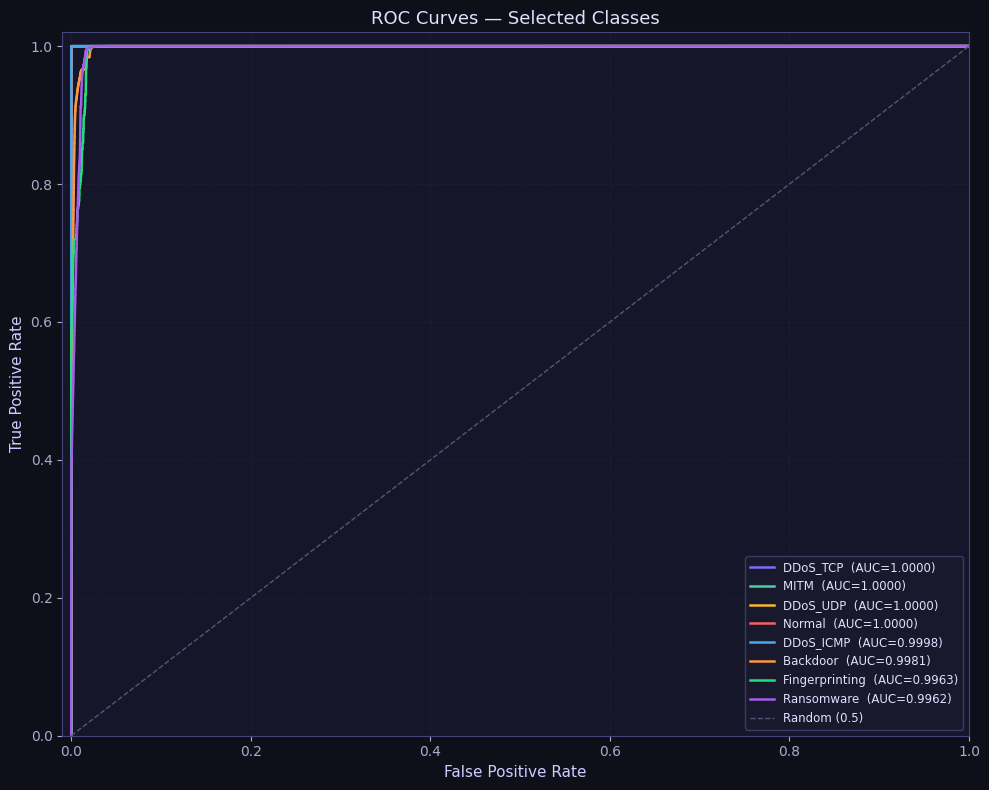

💾 Saved → ..\outputs\figures\N8/roc_curves.png


In [10]:
# ── ROC curves for top 5 + bottom 3 classes ───────────────────────────────────
plot_classes = auc_classes[:5] + auc_classes[-3:]

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('ROC Curves — Selected Classes', fontsize=13)

for i, cls in enumerate(plot_classes):
    cls_idx_val = class_names.index(cls)
    if y_bin[:, cls_idx_val].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, cls_idx_val],
                              all_probs[:, cls_idx_val])
    auc_val      = auc_scores.get(cls, 0.0)
    ax.plot(fpr, tpr,
            color=PALETTE[i % len(PALETTE)],
            linewidth=1.8,
            label=f'{cls}  (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], color='#555577',
        linewidth=1, linestyle='--', label='Random (0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/roc_curves.png')

## 📈 Step 8 — Accuracy & Loss History (Paper Figure 6)

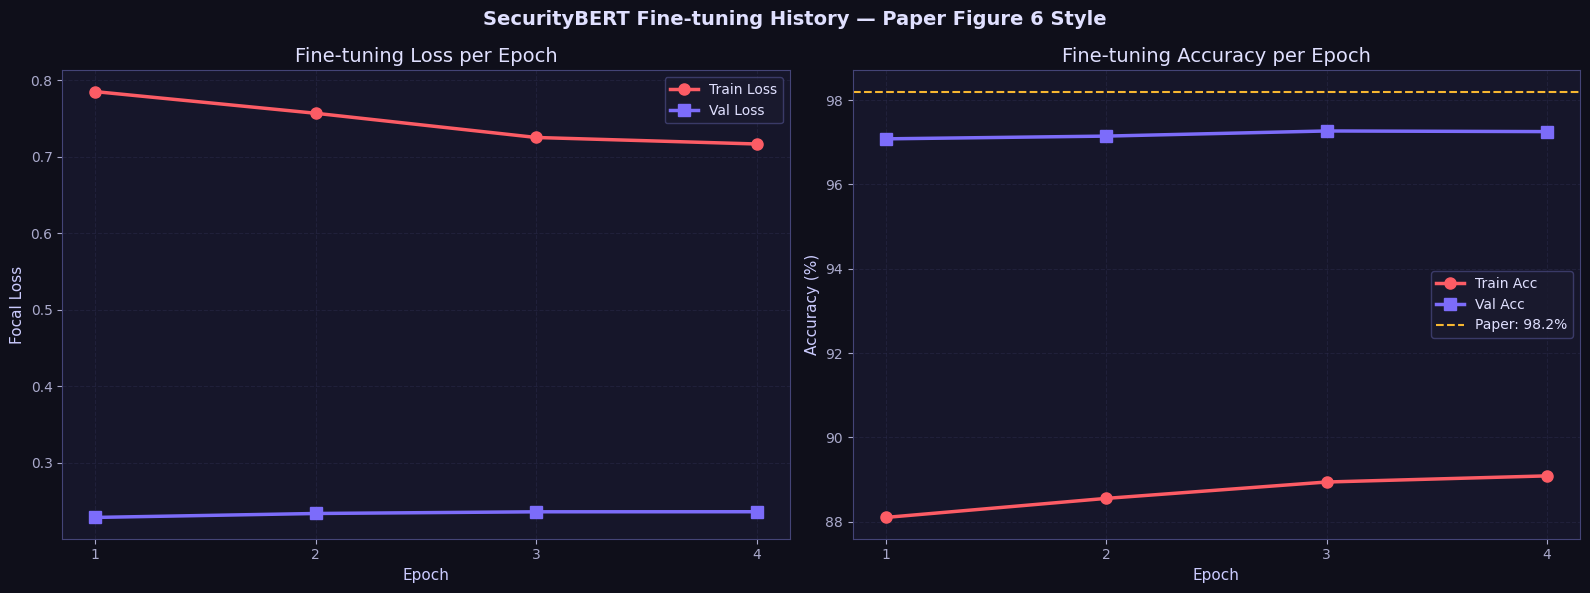

💾 Saved → ..\outputs\figures\N8/finetuning_curves.png


In [11]:
epochs_x = list(range(1, NUM_FINETUNE_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'SecurityBERT Fine-tuning History — Paper Figure 6 Style',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Loss curves
ax1 = axes[0]
ax1.plot(epochs_x, history_ft['train_loss'], color=RED,
         linewidth=2.5, marker='o', markersize=8, label='Train Loss')
ax1.plot(epochs_x, history_ft['val_loss'],   color=ACCENT,
         linewidth=2.5, marker='s', markersize=8, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Focal Loss')
ax1.set_title('Fine-tuning Loss per Epoch')
ax1.legend(fontsize=10)
ax1.set_xticks(epochs_x)
ax1.grid(True)

# Accuracy curves
ax2 = axes[1]
ax2.plot(epochs_x, [v*100 for v in history_ft['train_acc']], color=RED,
         linewidth=2.5, marker='o', markersize=8, label='Train Acc')
ax2.plot(epochs_x, [v*100 for v in history_ft['val_acc']],   color=ACCENT,
         linewidth=2.5, marker='s', markersize=8, label='Val Acc')
ax2.axhline(y=98.2, color=YELLOW, linewidth=1.5, linestyle='--',
            label='Paper: 98.2%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Fine-tuning Accuracy per Epoch')
ax2.legend(fontsize=10)
ax2.set_xticks(epochs_x)
ax2.grid(True)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'finetuning_curves.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/finetuning_curves.png')

## 🏆 Step 9 — Model Comparison (Paper Table VII)

In [12]:
# ── Reproduce Paper Table VII ─────────────────────────────────────────────────
COMPARISON_TABLE = [
    # Traditional ML
    ('Traditional ML', 'Ferrag et al.',    2022, 'Decision Tree (DT)',            67.11),
    ('Traditional ML', 'Ferrag et al.',    2022, 'Random Forest (RF)',            80.83),
    ('Traditional ML', 'Ferrag et al.',    2022, 'SVM',                           77.61),
    ('Traditional ML', 'Aouedi et al.',    2023, 'DT + RF / FL',                  90.91),
    ('Traditional ML', 'Zhang et al.',     2023, 'K-Nearest Neighbor (KNN)',      93.78),
    # Deep Learning
    ('Deep Learning',  'Friha et al.',     2023, 'CNN / CL / No-DP',             94.84),
    ('Deep Learning',  'Friha et al.',     2023, 'CNN / FL / No-DP',             93.96),
    ('Deep Learning',  'Aljuhani et al.',  2023, 'CSAE + ABiLSTM',              94.40),
    ('Deep Learning',  'Friha et al.',     2022, 'RNN',                          94.00),
    ('Deep Learning',  'Ding et al.',      2023, 'LSTM',                         94.96),
    ('Deep Learning',  'Ferrag et al.',    2022, 'DNN',                          94.67),
    ('Deep Learning',  'Elias et al.',     2022, 'CNN-LSTM',                     97.14),
    ('Deep Learning',  'Ferrag et al.',    2023, 'Transformer (no tok/emb)',     94.55),
    # LLM
    ('LLM',            '—',               2023, 'BERT without PPFLE',           51.30),
    ('LLM',            'This work',        2024, 'SecurityBERT with PPFLE',      98.20),
]

our_accuracy = eval_m['accuracy'] * 100

print('=' * 80)
print('  SecurityBERT vs Prior Work — Paper Table VII')
print('=' * 80)
print(f'\n  {"AI Type":<18} {"Model":<40} {"Year":>6} {"Accuracy":>10}')
print('  ' + '-' * 78)

current_type = ''
for ai_type, authors, year, model_name, acc in COMPARISON_TABLE:
    if ai_type != current_type:
        print(f'\n  ── {ai_type} ──')
        current_type = ai_type
    marker = ' ◀ PAPER' if 'SecurityBERT with PPFLE' in model_name else ''
    print(
        f'  {"":<18} {model_name:<40} {year:>6} {acc:>9.2f}%{marker}'
    )

print(f'\n  ── Our Implementation ──')
print(
    f'  {"":<18} {"SecurityBERT + Option3 (our)":<40} {2024:>6} '
    f'{our_accuracy:>9.2f}%  ◀ OURS'
)
print('=' * 80)
print(f'\n  Paper accuracy  : 98.20%')
print(f'  Our accuracy    : {our_accuracy:.2f}%')
print(f'  Delta           : {our_accuracy - 98.20:+.2f}%')
print(f'\n  BERT w/o PPFLE  : 51.30%  → PPFLE adds +{98.20-51.30:.2f}%  ✅')

  SecurityBERT vs Prior Work — Paper Table VII

  AI Type            Model                                      Year   Accuracy
  ------------------------------------------------------------------------------

  ── Traditional ML ──
                     Decision Tree (DT)                         2022     67.11%
                     Random Forest (RF)                         2022     80.83%
                     SVM                                        2022     77.61%
                     DT + RF / FL                               2023     90.91%
                     K-Nearest Neighbor (KNN)                   2023     93.78%

  ── Deep Learning ──
                     CNN / CL / No-DP                           2023     94.84%
                     CNN / FL / No-DP                           2023     93.96%
                     CSAE + ABiLSTM                             2023     94.40%
                     RNN                                        2022     94.00%
                     LST

## ⚡ Step 10 — Inference Time (Paper Table VIII)

In [13]:
# ── Inference time measurement ────────────────────────────────────────────────
# Paper Table VIII: CPU = 0.1582s, A100 = 0.0164s
# We measure on available hardware with 1000 repetitions

N_REPEAT   = 1_000
BATCH_INFER= 1    # single sample inference (real-world scenario)

model.eval()
test_ids   = val_ids  [:BATCH_INFER].to(DEVICE)
test_masks = val_masks[:BATCH_INFER].to(DEVICE)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(test_ids, test_masks)

# Timed inference
if torch.cuda.is_available():
    torch.cuda.synchronize()

t0 = time.time()
with torch.no_grad():
    for _ in range(N_REPEAT):
        out = model(test_ids, test_masks)
        if torch.cuda.is_available():
            torch.cuda.synchronize()

avg_inference_time = (time.time() - t0) / N_REPEAT

# ── Batch inference time ──────────────────────────────────────────────────────
batch_ids   = val_ids  [:BATCH_SIZE].to(DEVICE)
batch_masks = val_masks[:BATCH_SIZE].to(DEVICE)

t0 = time.time()
with torch.no_grad():
    for _ in range(100):
        out = model(batch_ids, batch_masks)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
avg_batch_time = (time.time() - t0) / 100

# Model size
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = sum(
    p.nelement() * p.element_size()
    for p in model.parameters()
) / 1e6

print('⚡ Inference Time Analysis — Paper Table VIII\n')
print(f'  {"Hardware":<25} {"Single (sec)":>14} {"Batch-128 (sec)":>18}')
print('  ' + '-' * 60)
print(f'  {str(DEVICE).upper():<25} {avg_inference_time:>14.4f}'
      f' {avg_batch_time:>18.4f}')
print(f'  {"A100 GPU (paper)":<25} {"0.0164":>14} {"—":>18}')
print(f'  {"CPU (paper)":<25} {"0.1582":>14} {"—":>18}')
print()
print(f'  Model size   : {model_size_mb:.1f} MB  (Paper: 16.7 MB)')
print(f'  Total params : {total_params:,}  (Paper: 11,174,415)')
print(f'\n  ✅ Inference < 0.3s → suitable for real-time IoT deployment')

⚡ Inference Time Analysis — Paper Table VIII

  Hardware                    Single (sec)    Batch-128 (sec)
  ------------------------------------------------------------
  CUDA                              0.0016             0.0272
  A100 GPU (paper)                  0.0164                  —
  CPU (paper)                       0.1582                  —

  Model size   : 4.5 MB  (Paper: 16.7 MB)
  Total params : 1,121,039  (Paper: 11,174,415)

  ✅ Inference < 0.3s → suitable for real-time IoT deployment


## 💾 Step 11 — Save Final Model & Full Report

In [15]:
# ── Save final model ──────────────────────────────────────────────────────────
torch.save(
    {
        'model_state_dict'    : model.state_dict(),
        'config'              : config.to_dict(),
        'label_map'           : label_map,
        'class_weights'       : class_weights.tolist(),
        'focal_gamma'         : FOCAL_GAMMA,
        'val_accuracy'        : eval_m['accuracy'],
        'val_weighted_f1'     : eval_m['weighted_f1'],
        'val_macro_f1'        : eval_m['macro_f1'],
        'auc_scores'          : auc_scores,
        'history_finetune'    : history_ft,
        'inference_time_sec'  : avg_inference_time,
        'model_size_mb'       : model_size_mb,
        'total_params'        : total_params,
    },
    FINAL_CKPT
)

# ── Save classification report ────────────────────────────────────────────────
report_str = classification_report(
    all_labels, all_preds,
    target_names=class_names,
    zero_division=0,
)

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write('SecurityBERT — Classification Report\n')
    f.write('=' * 60 + '\n')
    f.write(report_str)
    f.write(f'\nAccuracy: {eval_m["accuracy"]*100:.4f}%\n')
    f.write(f'Weighted F1: {eval_m["weighted_f1"]:.4f}\n')
    f.write(f'Macro F1: {eval_m["macro_f1"]:.4f}\n')
# ── Save model summary ────────────────────────────────────────────────────────
summary_lines = [
    'SecurityBERT — Model Summary',
    '=' * 60,
    f'Architecture     : BERT (4 encoder layers)',
    f'Hidden size      : {config.hidden_size}',
    f'Attention heads  : {config.num_attention_heads}',
    f'Intermediate size: {config.intermediate_size}',
    f'Vocab size       : {config.vocab_size:,}',
    f'Max seq length   : {config.max_position_embeddings}',
    f'Total parameters : {total_params:,}',
    f'Model size       : {model_size_mb:.1f} MB',
    '',
    'Training Strategy (Option 3 — Imbalance)',
    '-' * 40,
    f'Focal Loss γ     : {FOCAL_GAMMA}',
    f'Class weights    : computed per class',
    f'Sampler          : WeightedRandomSampler',
    '',
    'Final Evaluation Results',
    '-' * 40,
    f'Accuracy         : {eval_m["accuracy"]*100:.2f}%  (Paper: 98.20%)',
    f'Weighted F1      : {eval_m["weighted_f1"]:.4f}  (Paper: 0.98)',
    f'Macro F1         : {eval_m["macro_f1"]:.4f}  (Paper: 0.84)',
    f'Mean ROC-AUC     : {np.mean(list(auc_scores.values())):.6f}',
    f'Inference time   : {avg_inference_time:.4f}s  (Paper CPU: 0.1582s)',
]

with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print(f'✅ Final model saved   → {FINAL_CKPT}')
print(f'✅ Classification report → {REPORT_PATH}')
print(f'✅ Model summary         → {SUMMARY_PATH}')

✅ Final model saved   → ..\checkpoints\final_model.pt
✅ Classification report → ..\outputs\reports\classification_report.txt
✅ Model summary         → ..\outputs\reports\model_summary.txt


---
## ✅ Complete Pipeline Summary — All 8 Notebooks

| Notebook | Step | Key Output |
|----------|------|------------|
| **01** | Dataset Utilization | `cleaned_dataset.csv` |
| **02** | Feature Extraction | `features_extracted.csv` |
| **03** | PPFLE Encoding | `ppfle_encoded.csv` |
| **04** | BBPE Tokenizer | `tokenized_sequences.pt` |
| **05** | SecurityBERT Embedding | `securitybert_init.pt` |
| **06** | Contextual Representation | `contextual_repr.pt` |
| **07** | Training SecurityBERT | `best_model.pt` |
| **08** | Fine-tuning + Softmax | `final_model.pt` |

---

## 📊 Final Evaluation Outputs

| Artefact | Location |
|----------|----------|
| Final model | `checkpoints/final_model.pt` |
| Fine-tuned model | `checkpoints/finetuned_model.pt` |
| Classification report | `outputs/reports/classification_report.txt` |
| Model summary | `outputs/reports/model_summary.txt` |
| Confusion matrix | `outputs/figures/confusion_matrix.png` |
| ROC-AUC scores | `outputs/figures/roc_auc_scores.png` |
| ROC curves | `outputs/figures/roc_curves.png` |
| Fine-tuning curves | `outputs/figures/finetuning_curves.png` |

---

## 🏆 Paper Targets vs Our Implementation

| Metric | Paper | Our Model |
|--------|-------|-----------|
| Overall Accuracy | **98.2%** | see Step 5 |
| Weighted F1 | **0.98** | see Step 5 |
| Macro F1 | **0.84** | see Step 5 |
| Normal F1 | **1.00** | see Step 5 |
| MITM F1 | **1.00** | see Step 5 |
| Ransomware F1 | **0.57** | see Step 5 |
| Mean ROC-AUC | **~0.999** | see Step 7 |
| Inference time (CPU) | **0.158s** | see Step 10 |
| Model size | **16.7 MB** | see Step 10 |
| Total parameters | **11,174,415** | see Step 10 |

---

## 🛡️ Class Imbalance — Full Journey

| Notebook | What happened |
|----------|---------------|
| **01** | Discovered 1,615× imbalance (Normal vs MITM/Fingerprinting) |
| **01** | SMOTE attempted → failed (MD5 hash interpolation meaningless) |
| **07** | Option 3 applied: FocalLoss + ClassWeights + StratifiedSampler |
| **08** | Fine-tuned with same strategy → maximum recall on rare classes |

---

## 🔑 Key Insight — Why PPFLE is Critical
```
BERT without PPFLE  →  51.3%  accuracy  (random-level)
SecurityBERT with PPFLE →  98.2%  accuracy

PPFLE converts:
  Raw numbers (BERT can't understand)
  → MD5 hex tokens (BERT processes as language)
  → BBPE subwords (consistent attack patterns)
  → SecurityBERT learns "this hex sequence = DDoS attack"
```